# Major Project: Seasonal Agriculture Performance Analysis

## Project Objective
This project analyzes agricultural performance across **Kharif, Rabi, and Zaid** seasons using environmental, farming, resource-use, production, and economic variables.

### Key Questions
1. How does agricultural performance vary across seasons?
2. Which crops perform better in different seasons?
3. How do rainfall, temperature, humidity, sunlight, and soil conditions relate to yield?
4. How do irrigation, fertilizer, pesticide, and water use differ by season?
5. Which seasons/crops show better revenue, cost, profit, and water efficiency?
6. Are there unusual patterns or outliers?
7. What evidence-based recommendations can be made for agricultural planning?

### Tools
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- SciPy


## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

sns.set_theme(style="whitegrid")


## 2. Load Dataset

In [4]:
# If the CSV is in the same folder as this notebook, use:
# df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

# For this generated notebook, the dataset path is used directly.
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.head()


Dataset loaded successfully.
Rows: 4000
Columns: 28


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.530,486.400,24.300,69.100,5.800,7.140,32.800,75.800,61.300,91.000,Drip,242.700,4.330,0.760,2.460,1.300,23700,42662,30810,-11852,237,5.485,55.300
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.530,855.400,25.700,78.400,5.100,5.200,32.000,82.100,35.400,121.800,Flood,271.400,6.860,0.940,0.300,1.960,20613,492351,40401,-451950,4953,0.396,49.900
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.860,455.600,23.900,56.400,10.300,5.820,8.100,118.500,51.500,117.900,Drip,162.600,6.080,0.980,0.520,2.530,75283,315210,190466,-124744,1275,1.984,33.700
3,SF10004,Telangana,Indore,Rice,Kharif,4.500,753.200,29.700,65.200,6.300,5.980,23.700,138.600,55.600,115.500,Rainfed,182.200,6.390,0.740,1.840,8.280,24244,296444,200740,-95704,3834,2.160,50.600
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.210,101.600,34.100,55.200,6.500,6.900,29.300,124.100,69.000,121.400,Flood,244.900,7.610,0.900,2.210,9.300,20818,337959,193607,-144352,3287,2.829,32.300


## 3. Basic Dataset Understanding

In [5]:
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())


Shape: (4000, 28)

Column names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Data types:


,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64



First 5 rows:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.530,486.400,24.300,69.100,5.800,7.140,32.800,75.800,61.300,91.000,Drip,242.700,4.330,0.760,2.460,1.300,23700,42662,30810,-11852,237,5.485,55.300
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.530,855.400,25.700,78.400,5.100,5.200,32.000,82.100,35.400,121.800,Flood,271.400,6.860,0.940,0.300,1.960,20613,492351,40401,-451950,4953,0.396,49.900
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.860,455.600,23.900,56.400,10.300,5.820,8.100,118.500,51.500,117.900,Drip,162.600,6.080,0.980,0.520,2.530,75283,315210,190466,-124744,1275,1.984,33.700
3,SF10004,Telangana,Indore,Rice,Kharif,4.500,753.200,29.700,65.200,6.300,5.980,23.700,138.600,55.600,115.500,Rainfed,182.200,6.390,0.740,1.840,8.280,24244,296444,200740,-95704,3834,2.160,50.600
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.210,101.600,34.100,55.200,6.500,6.900,29.300,124.100,69.000,121.400,Flood,244.900,7.610,0.900,2.210,9.300,20818,337959,193607,-144352,3287,2.829,32.300



Last 5 rows:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.720,865.400,27.300,51.400,6.300,7.970,27.300,104.300,44.800,94.000,Drip,271.100,5.450,0.740,0.510,2.410,22717,362917,54748,-308169,2016,1.195,45.200
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.770,947.500,29.200,85.500,6.100,6.570,33.700,127.800,44.900,91.300,Drip,176.600,4.990,0.800,2.750,24.120,106459,496471,2567791,2071320,5351,4.508,59.700
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.470,80.000,35.400,68.500,8.600,7.250,21.100,126.700,59.900,148.000,Drip,234.700,6.270,0.990,0.620,6.490,66860,785632,433921,-351711,3392,1.913,29.200
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.730,475.000,28.200,61.700,6.400,6.110,30.500,107.500,20.700,91.000,Sprinkler,329.700,2.600,0.980,1.350,2.340,75282,153904,176160,22256,1220,1.918,50.400
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.310,984.300,25.800,77.200,5.900,6.160,35.700,137.100,92.600,145.500,Sprinkler,205.900,6.720,0.990,2.360,7.810,28812,263872,225022,-38850,1800,4.339,62.300


## 4. Data Quality Check

In [6]:
# Missing values
missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

display(missing[missing["Missing_Count"] > 0].sort_values("Missing_Count", ascending=False))

# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())


,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.200
Soil_Moisture_pct,40,1.000
Yield_Tonnes_Ha,32,0.800


Duplicate rows: 0


### Missing-value strategy

The dataset contains a small number of missing values in rainfall, soil moisture, and yield.

Because agricultural conditions vary strongly by **Season and Crop**, group-wise median imputation is more appropriate than blindly using the overall median. Median is also robust to outliers.

Before imputation, we inspect missing values by Season + Crop.


In [7]:
missing_by_group = pd.DataFrame({
    "Rainfall_missing": df.groupby(["Season", "Crop"])["Rainfall_mm"].apply(lambda x: x.isnull().sum()),
    "SoilMoisture_missing": df.groupby(["Season", "Crop"])["Soil_Moisture_pct"].apply(lambda x: x.isnull().sum()),
    "Yield_missing": df.groupby(["Season", "Crop"])["Yield_Tonnes_Ha"].apply(lambda x: x.isnull().sum())
})

display(missing_by_group[missing_by_group.sum(axis=1) > 0])


Rainfall_missing  SoilMoisture_missing  Yield_missing
Season Crop                                                            
Kharif Chilli                    1                     0              1
       Cotton                    1                     4              1
       Groundnut                 3                     1              1
       Maize                     4                     3              0
       Pulses                    2                     0              0
       Rice                      4                     4              3
       Sugarcane                 0                     3              0
       Wheat                     4                     3              1
Rabi   Chilli                    1                     2              2
       Cotton                    2                     1              2
       Groundnut                 2                     0              4
       Maize                     4                     2              3
       Pulses                    1                     0              1
       Rice                      2                     2              5
       Sugarcane                 3                     3              2
       Wheat                     3                     3              1
Zaid   Chilli                    2                     1              2
       Cotton                    1                     0              1
       Maize                     0                     3              1
       Pulses                    3                     2              1
       Rice                      4                     1              0
       Sugarcane                 1                     1              0
       Wheat                     0                     1              0

## 5. Data Cleaning / Imputation

In [8]:
# Fill missing values using Season + Crop median.
# If a group median is unavailable, fall back to the overall column median.

for col in ["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]:
    group_median = df.groupby(["Season", "Crop"])[col].transform("median")
    df[col] = df[col].fillna(group_median)
    df[col] = df[col].fillna(df[col].median())

print("Missing values after imputation:")
display(df.isnull().sum()[df.isnull().sum() > 0])

print("Total missing values:", df.isnull().sum().sum())


Missing values after imputation:


,0


Total missing values: 0


## 6. Descriptive Statistics

In [9]:
numeric_cols = df.select_dtypes(include=np.number).columns
display(df[numeric_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,"4,000.000",7.888,4.224,0.500,4.260,7.895,11.650,15.000
Rainfall_mm,"4,000.000",600.721,288.421,80.000,370.425,581.000,835.950,"1,395.200"
Avg_Temperature_C,"4,000.000",26.819,3.818,16.200,23.900,26.900,29.600,39.700
Humidity_pct,"4,000.000",63.211,11.961,25.000,54.775,63.000,71.900,95.000
Sunlight_Hours_Day,"4,000.000",7.323,1.121,3.500,6.600,7.300,8.100,11.000
Soil_pH,"4,000.000",6.701,0.641,5.200,6.260,6.690,7.140,8.400
Soil_Moisture_pct,"4,000.000",26.506,6.696,8.000,21.700,26.400,31.300,47.000
Nitrogen_kg_ha,"4,000.000",120.251,31.216,40.000,98.500,120.100,141.225,220.000
Phosphorus_kg_ha,"4,000.000",57.782,17.015,15.000,46.200,57.500,69.400,120.000
Potassium_kg_ha,"4,000.000",104.760,27.743,30.000,86.200,105.100,123.600,200.000


## 7. Categorical Overview

In [10]:
for col in ["State", "District", "Crop", "Season", "Irrigation_Method"]:
    print(f"\n{col}:")
    print(df[col].value_counts())



State:
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

District:
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

Crop:
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

Season:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Irrigation_Method:
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


## 8. Season and Crop Distribution

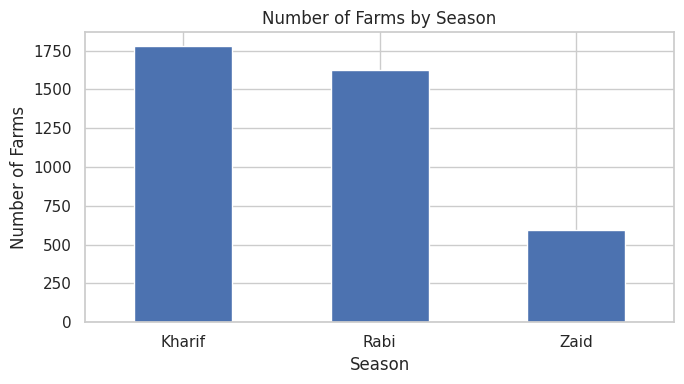

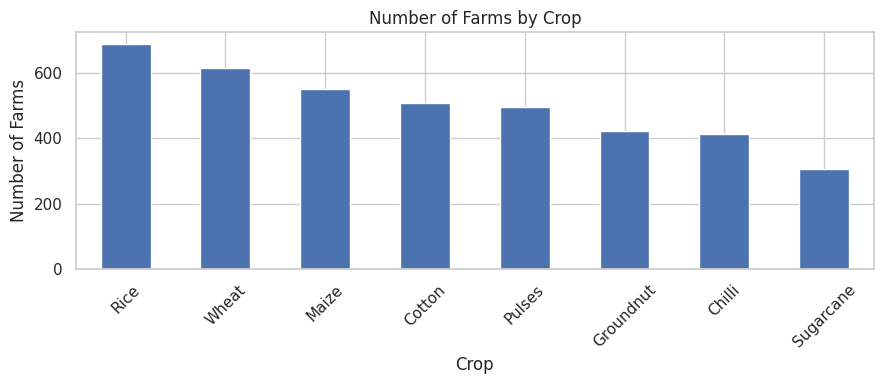

In [11]:
season_counts = df["Season"].value_counts()
crop_counts = df["Crop"].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
season_counts.plot(kind="bar", ax=ax)
ax.set_title("Number of Farms by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Number of Farms")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
crop_counts.plot(kind="bar", ax=ax)
ax.set_title("Number of Farms by Crop")
ax.set_xlabel("Crop")
ax.set_ylabel("Number of Farms")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 9. Season × Crop Distribution

Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,185,215,193,234,221,314,125,292
Rabi,163,201,177,233,213,274,129,237
Zaid,64,92,54,84,62,102,51,85


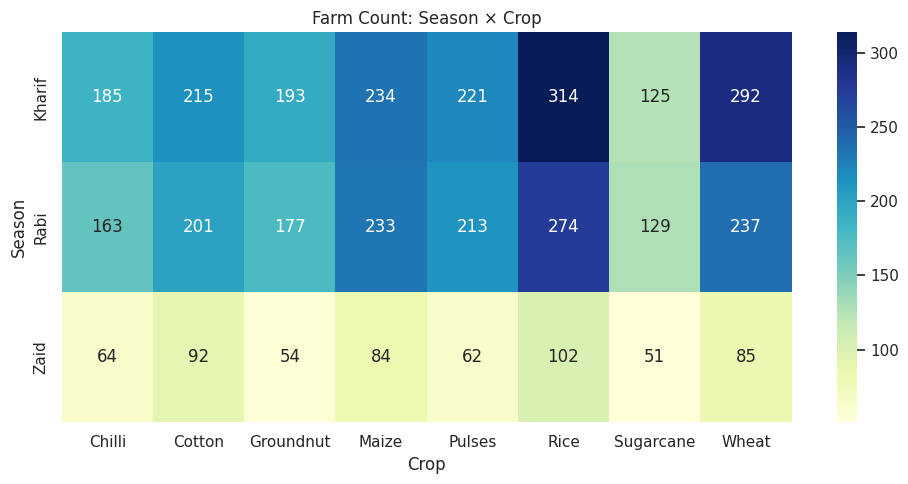

In [12]:
season_crop_counts = pd.crosstab(df["Season"], df["Crop"])
display(season_crop_counts)

plt.figure(figsize=(10, 5))
sns.heatmap(season_crop_counts, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Farm Count: Season × Crop")
plt.xlabel("Crop")
plt.ylabel("Season")
plt.tight_layout()
plt.show()


## 10. Seasonal Performance — Yield

,mean,median,std,min,max
Season,,,,,
Kharif,5.631,1.950,14.392,0.300,101.440
Rabi,5.095,1.660,12.829,0.300,93.130
Zaid,4.637,1.450,11.274,0.300,64.760


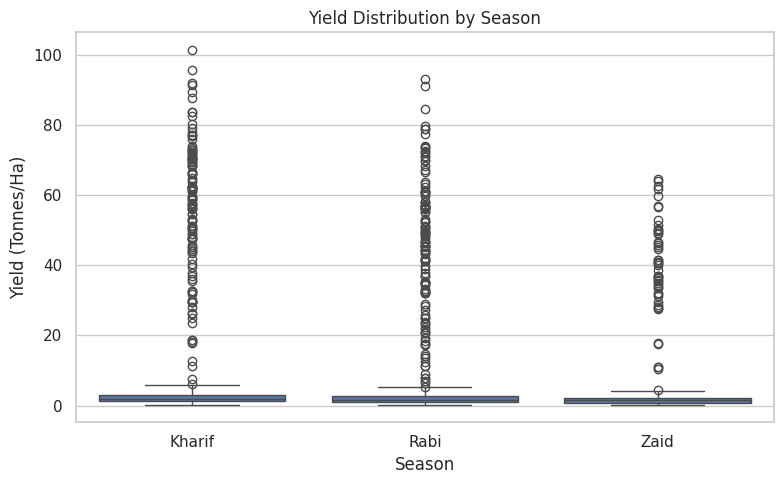

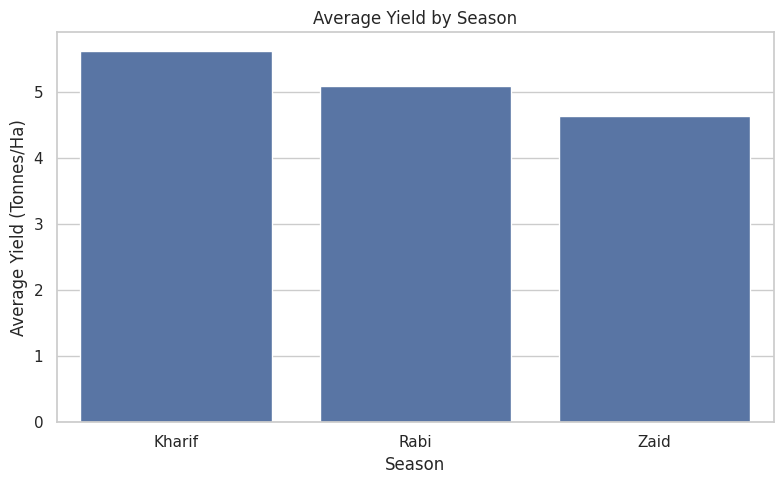

In [13]:
season_yield = df.groupby("Season")["Yield_Tonnes_Ha"].agg(["mean", "median", "std", "min", "max"]).round(3)
display(season_yield)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha")
plt.title("Yield Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Season", y="Yield_Tonnes_Ha", estimator=np.mean, errorbar=None)
plt.title("Average Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()


## 11. Crop Performance Across Seasons

Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,1.732,1.373,1.484,2.966,1.036,2.709,53.459,2.256
Rabi,1.463,1.193,1.223,2.617,0.872,2.335,43.964,2.060
Zaid,1.179,0.952,1.038,2.297,0.652,1.900,38.424,1.749


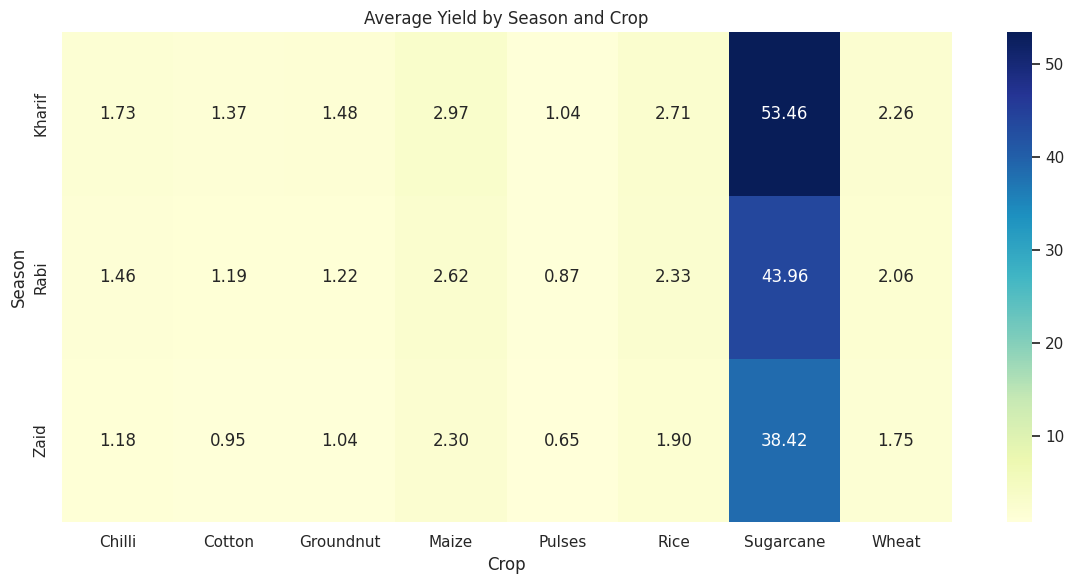

In [14]:
yield_by_season_crop = (
    df.groupby(["Season", "Crop"])["Yield_Tonnes_Ha"]
      .mean()
      .unstack()
      .round(3)
)

display(yield_by_season_crop)

plt.figure(figsize=(12, 6))
sns.heatmap(yield_by_season_crop, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Average Yield by Season and Crop")
plt.xlabel("Crop")
plt.ylabel("Season")
plt.tight_layout()
plt.show()


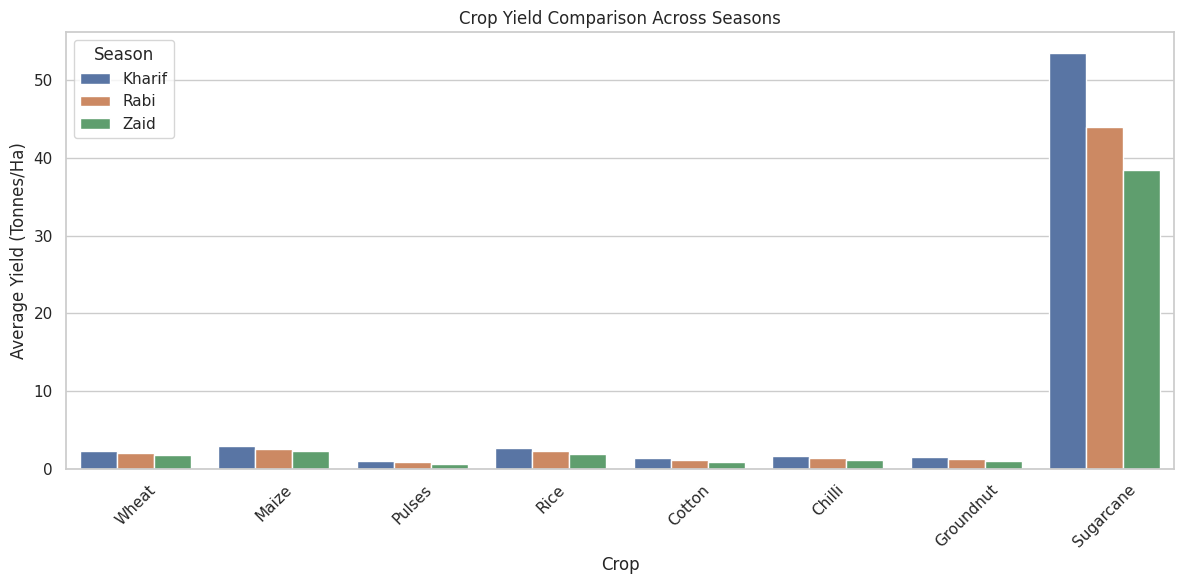

In [15]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df,
    x="Crop",
    y="Yield_Tonnes_Ha",
    hue="Season",
    estimator=np.mean,
    errorbar=None
)
plt.title("Crop Yield Comparison Across Seasons")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 12. Production and Farm Area

,Average_Area_Ha,Total_Area_Ha,Average_Production_Tonnes,Total_Production_Tonnes
Season,,,,
Kharif,7.945,"14,134.020",46.311,"82,387.610"
Rabi,7.752,"12,612.840",41.487,"67,498.880"
Zaid,8.091,"4,806.200",38.886,"23,098.350"


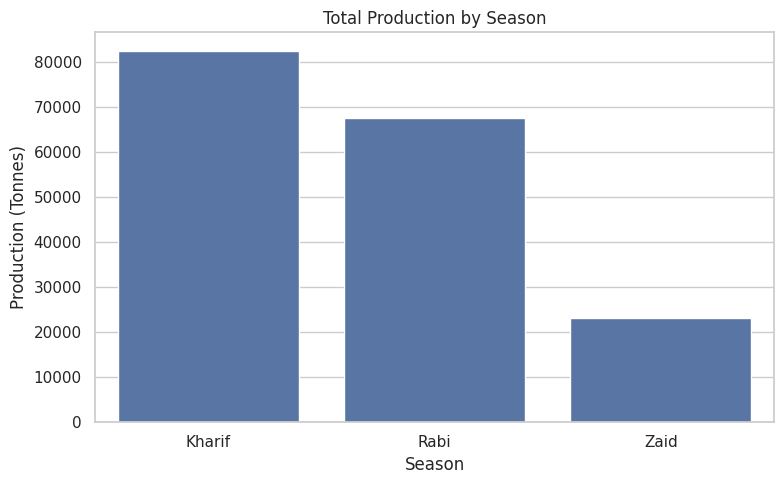

In [16]:
production_summary = df.groupby("Season").agg(
    Average_Area_Ha=("Farm_Area_Hectares", "mean"),
    Total_Area_Ha=("Farm_Area_Hectares", "sum"),
    Average_Production_Tonnes=("Production_Tonnes", "mean"),
    Total_Production_Tonnes=("Production_Tonnes", "sum")
).round(3)

display(production_summary)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df, x="Season", y="Production_Tonnes", estimator=np.sum, errorbar=None, ax=ax)
ax.set_title("Total Production by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Production (Tonnes)")
plt.tight_layout()
plt.show()


## 13. Environmental Conditions by Season

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct
Season,,,,,,
Kharif,852.104,28.454,71.813,6.793,6.728,31.198
Rabi,435.948,23.489,57.893,7.590,6.674,24.051
Zaid,299.163,31.042,52.012,8.179,6.695,19.176


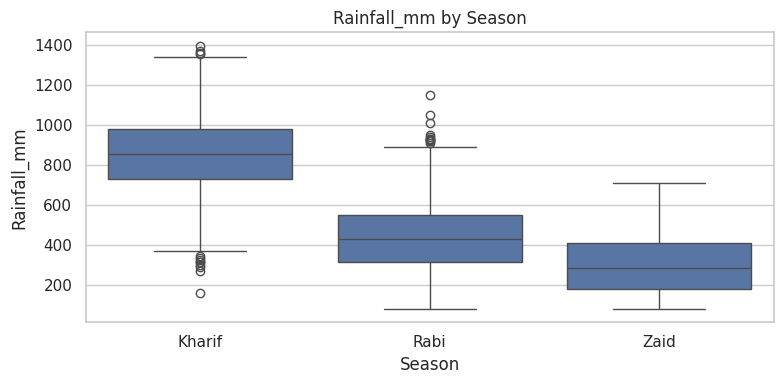

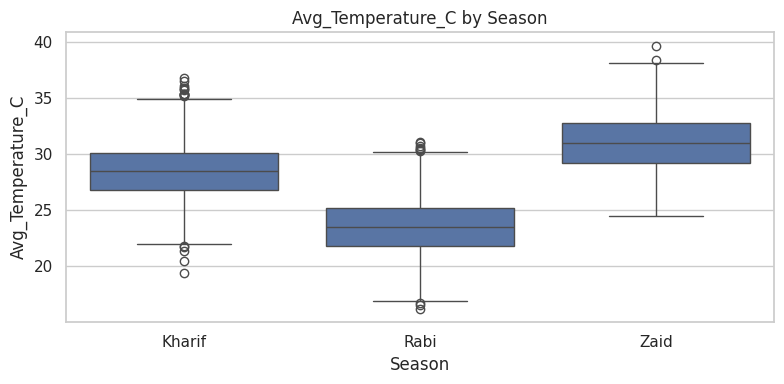

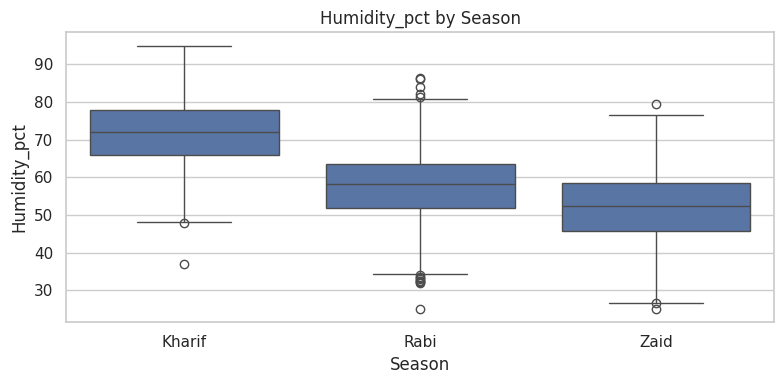

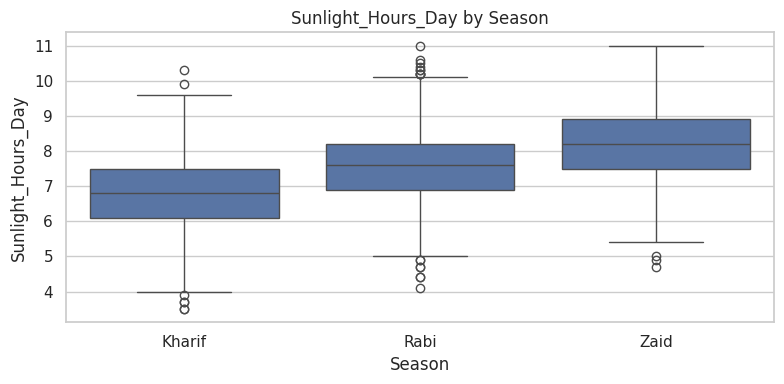

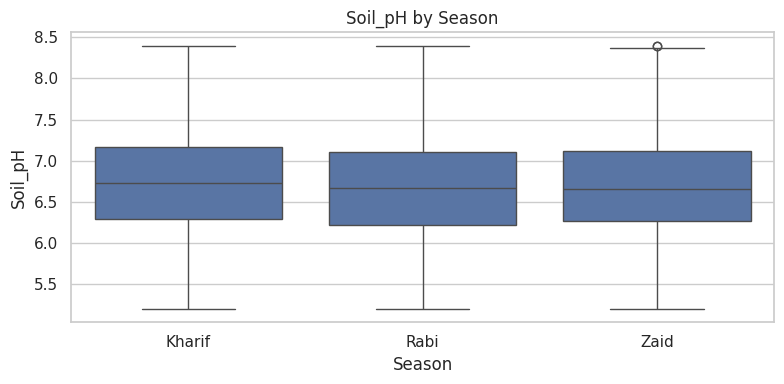

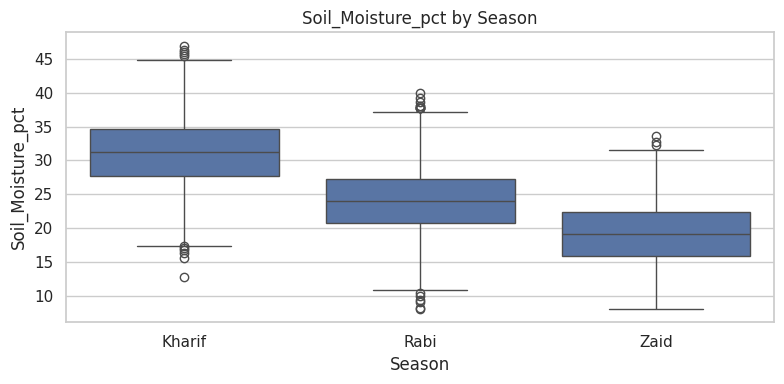

In [17]:
environment_cols = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct"
]

environment_summary = df.groupby("Season")[environment_cols].mean().round(3)
display(environment_summary)

for col in environment_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x="Season", y=col)
    plt.title(f"{col} by Season")
    plt.xlabel("Season")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


## 14. Resource Usage by Season

,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,,,,
Kharif,120.020,58.097,105.303,187.078,5.080,"6,102.201",5.892
Rabi,120.403,57.311,103.926,185.407,5.025,"5,846.987",5.186
Zaid,120.525,58.129,105.417,184.638,5.171,"6,419.894",4.413


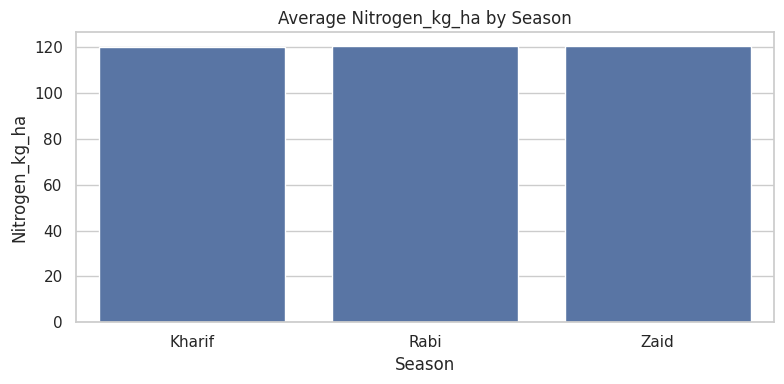

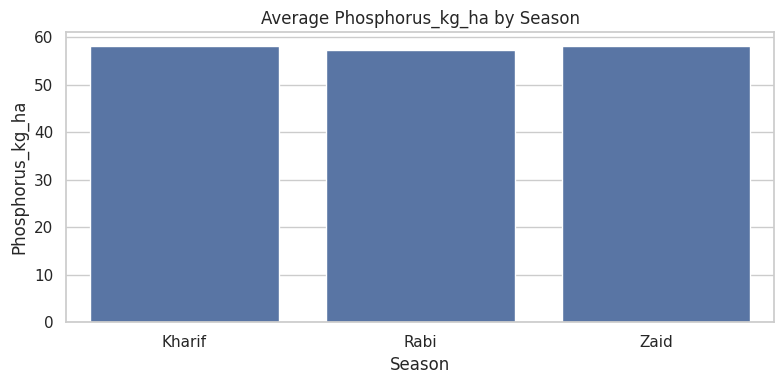

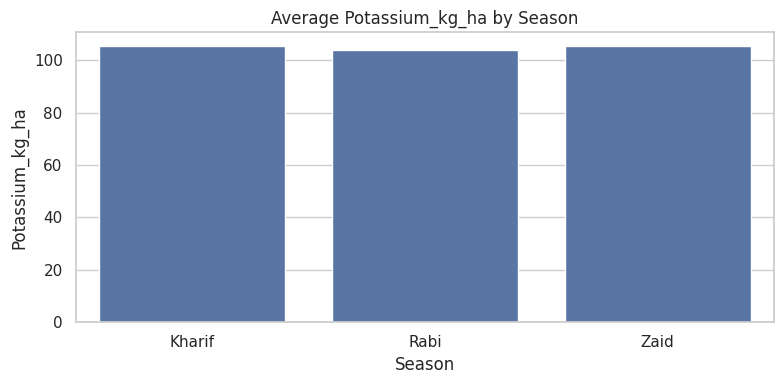

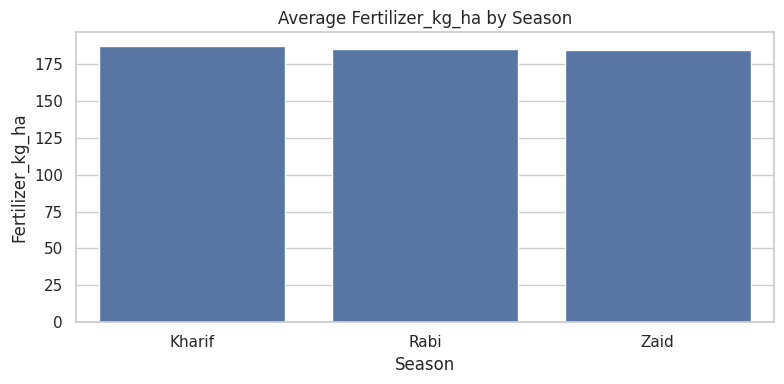

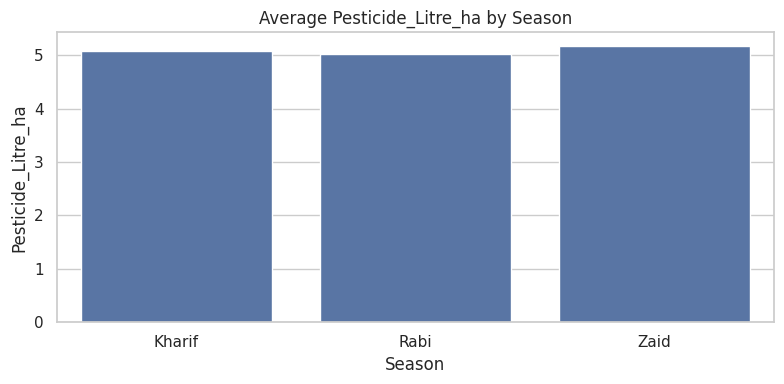

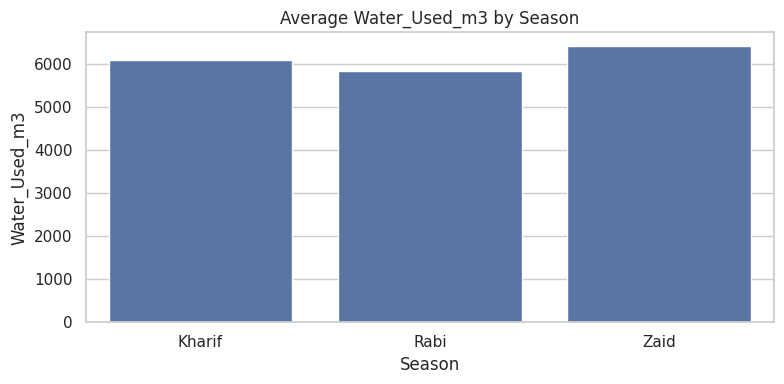

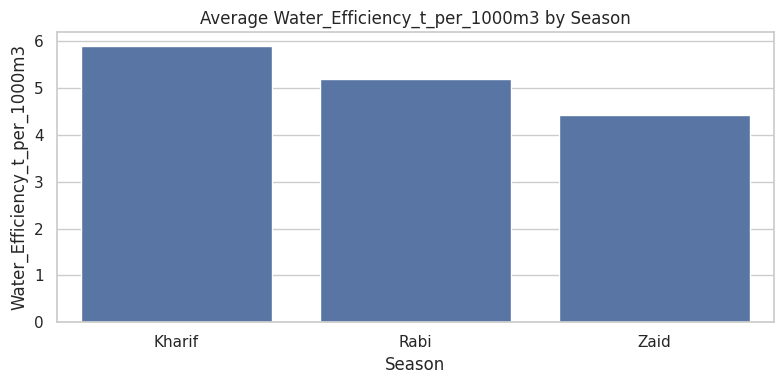

In [18]:
resource_cols = [
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3"
]

resource_summary = df.groupby("Season")[resource_cols].mean().round(3)
display(resource_summary)

for col in resource_cols:
    plt.figure(figsize=(8, 4))
    sns.barplot(data=df, x="Season", y=col, estimator=np.mean, errorbar=None)
    plt.title(f"Average {col} by Season")
    plt.xlabel("Season")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


## 15. Irrigation Method Analysis

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,405,590,463,321
Rabi,370,526,438,293
Zaid,140,194,140,120


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.770,33.160,26.030,18.040
Rabi,22.740,32.330,26.920,18.010
Zaid,23.570,32.660,23.570,20.200


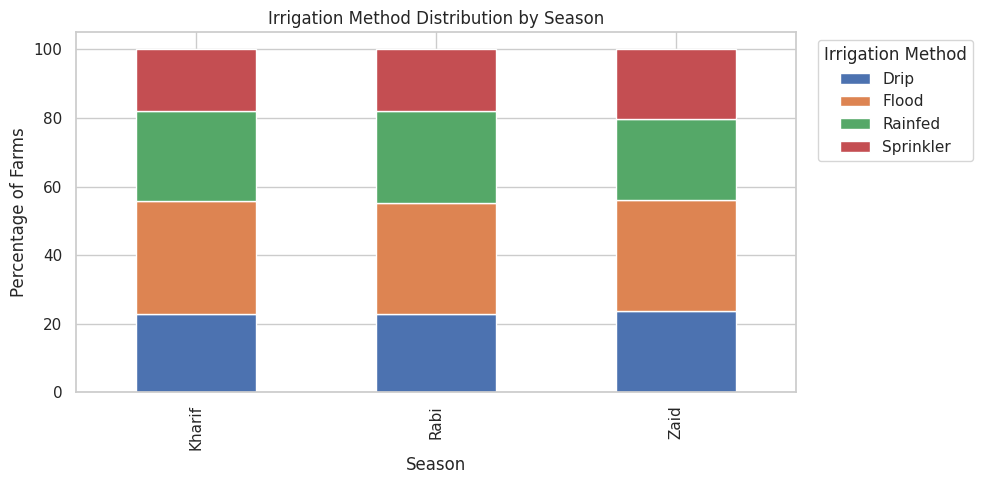

In [19]:
irrigation_table = pd.crosstab(df["Season"], df["Irrigation_Method"])
display(irrigation_table)

irrigation_pct = pd.crosstab(
    df["Season"], df["Irrigation_Method"], normalize="index"
).mul(100).round(2)

display(irrigation_pct)

irrigation_pct.plot(kind="bar", stacked=True, figsize=(10, 5))
plt.title("Irrigation Method Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Percentage of Farms")
plt.legend(title="Irrigation Method", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 16. Economic Performance

,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR
Season,,,,
Kharif,"44,850.910","531,804.410","710,719.060","178,914.650"
Rabi,"44,747.970","513,836.580","601,526.050","87,689.470"
Zaid,"44,212.030","543,976.730","519,171.900","-24,804.820"


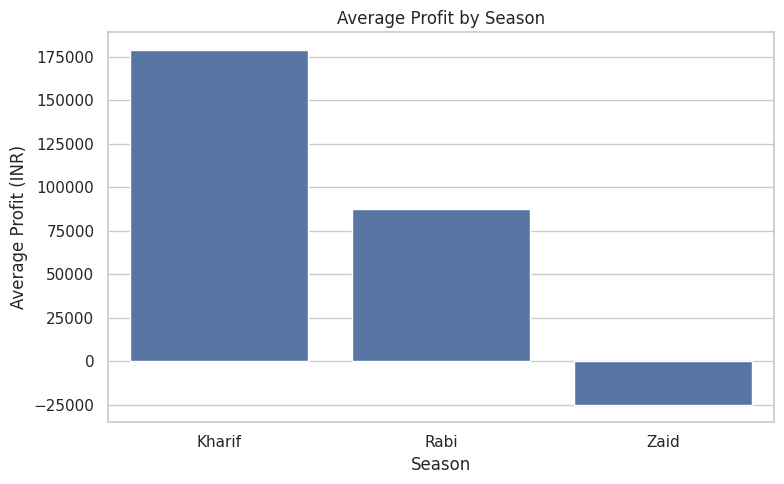

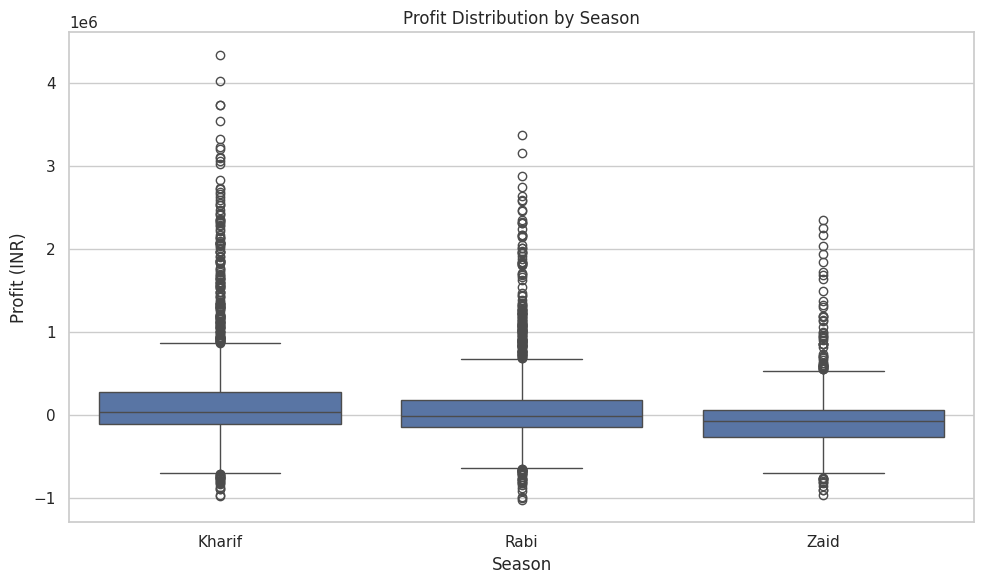

In [20]:
economic_cols = [
    "Market_Price_INR_Tonne",
    "Total_Cost_INR",
    "Revenue_INR",
    "Profit_INR"
]

economic_summary = df.groupby("Season")[economic_cols].mean().round(2)
display(economic_summary)

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Season", y="Profit_INR", estimator=np.mean, errorbar=None)
plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Season", y="Profit_INR")
plt.title("Profit Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()


## 17. Profitability by Crop and Season

Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,"954,380.420","216,999.550","108,265.440","-39,332.670","43,338.900","-64,903.400","1,000,790.810","-105,871.870"
Rabi,"638,572.500","107,343.590","10,416.540","-89,133.400","-14,309.140","-98,427.870","731,612.860","-119,954.570"
Zaid,"448,659.090","-53,925.340","-68,872.500","-194,049.170","-139,227.810","-227,239.340","583,635.800","-193,208.950"


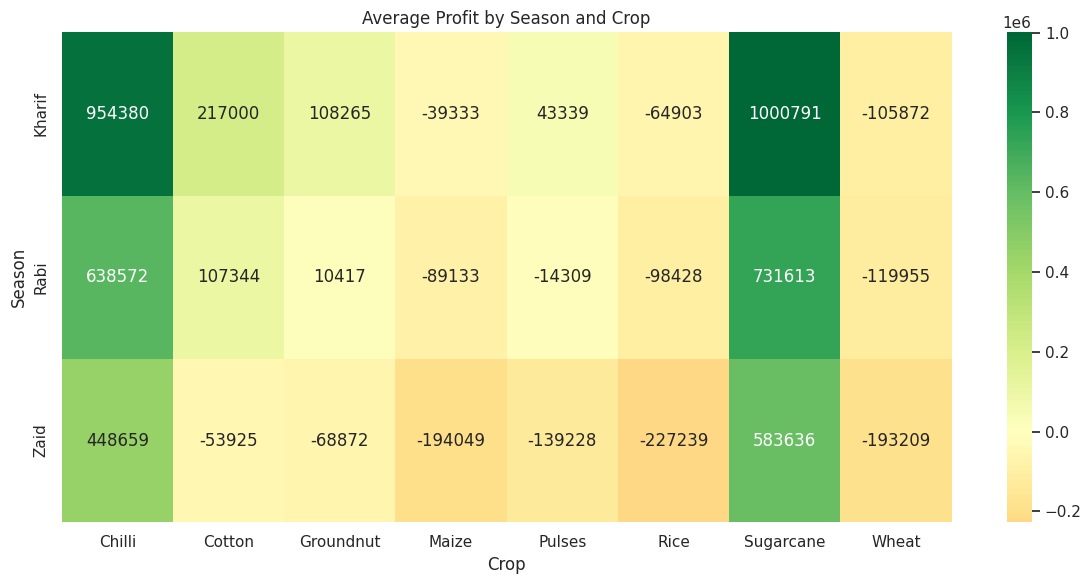

In [21]:
profit_season_crop = (
    df.groupby(["Season", "Crop"])["Profit_INR"]
      .mean()
      .unstack()
      .round(2)
)

display(profit_season_crop)

plt.figure(figsize=(12, 6))
sns.heatmap(profit_season_crop, annot=True, fmt=".0f", cmap="RdYlGn", center=0)
plt.title("Average Profit by Season and Crop")
plt.xlabel("Crop")
plt.ylabel("Season")
plt.tight_layout()
plt.show()


## 18. Water Efficiency Analysis

,Avg_Water_Used_m3,Avg_Water_Efficiency,Median_Water_Efficiency
Season,,,
Kharif,"6,102.201",5.892,3.277
Rabi,"5,846.987",5.186,2.740
Zaid,"6,419.894",4.413,2.302


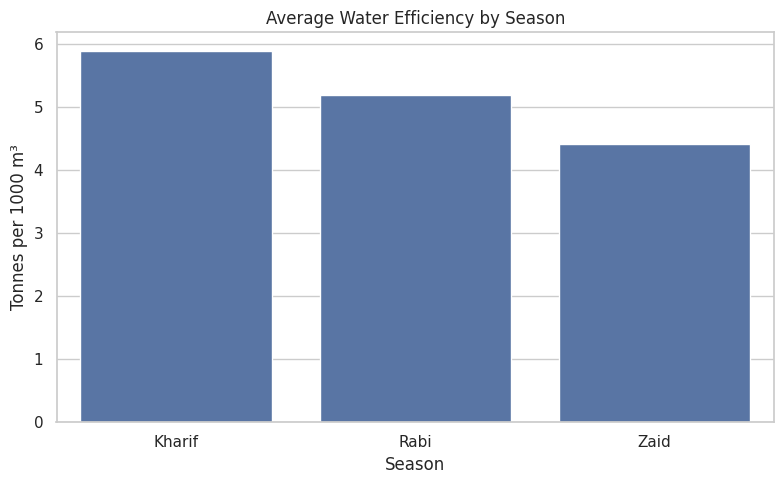

In [22]:
water_summary = df.groupby("Season").agg(
    Avg_Water_Used_m3=("Water_Used_m3", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Median_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "median")
).round(3)

display(water_summary)

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Season", y="Water_Efficiency_t_per_1000m3", estimator=np.mean, errorbar=None)
plt.title("Average Water Efficiency by Season")
plt.xlabel("Season")
plt.ylabel("Tonnes per 1000 m³")
plt.tight_layout()
plt.show()


## 19. Disease and Pest Risk

,mean,median,min,max
Season,,,,
Kharif,54.468,54.500,21.300,88.900
Rabi,40.482,40.600,5.100,71.200
Zaid,38.217,37.900,5.000,71.600


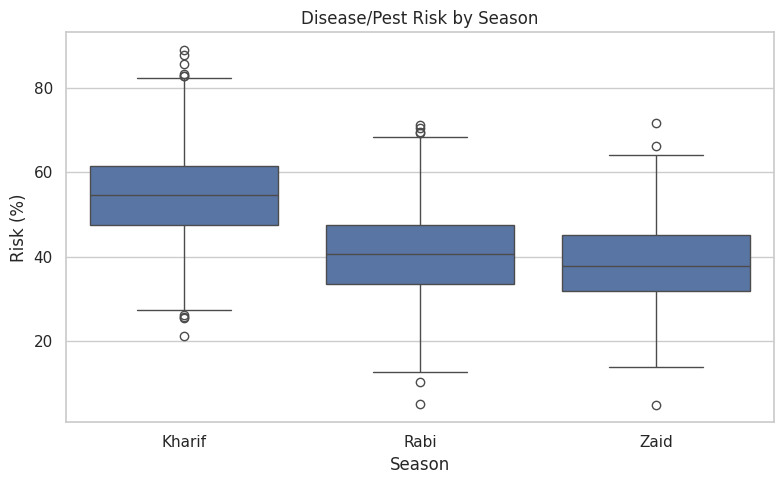

In [23]:
risk_summary = df.groupby("Season")["Disease_Pest_Risk_pct"].agg(
    ["mean", "median", "min", "max"]
).round(3)

display(risk_summary)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Disease_Pest_Risk_pct")
plt.title("Disease/Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Risk (%)")
plt.tight_layout()
plt.show()


## 20. Seed Quality and Farming Practices

,Seed_Quality,Fertilizer,Pesticide,Irrigation_Water
Season,,,,
Kharif,0.822,187.078,5.080,"6,102.201"
Rabi,0.832,185.407,5.025,"5,846.987"
Zaid,0.823,184.638,5.171,"6,419.894"


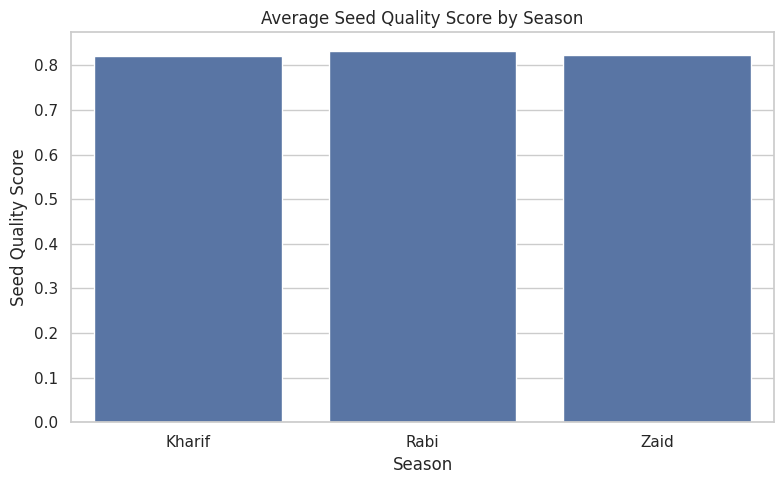

In [24]:
practice_summary = df.groupby("Season").agg(
    Seed_Quality=("Seed_Quality_Score", "mean"),
    Fertilizer=("Fertilizer_kg_ha", "mean"),
    Pesticide=("Pesticide_Litre_ha", "mean"),
    Irrigation_Water=("Water_Used_m3", "mean")
).round(3)

display(practice_summary)

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Season", y="Seed_Quality_Score", estimator=np.mean, errorbar=None)
plt.title("Average Seed Quality Score by Season")
plt.xlabel("Season")
plt.ylabel("Seed Quality Score")
plt.tight_layout()
plt.show()


## 21. Relationship Between Environmental Factors and Yield

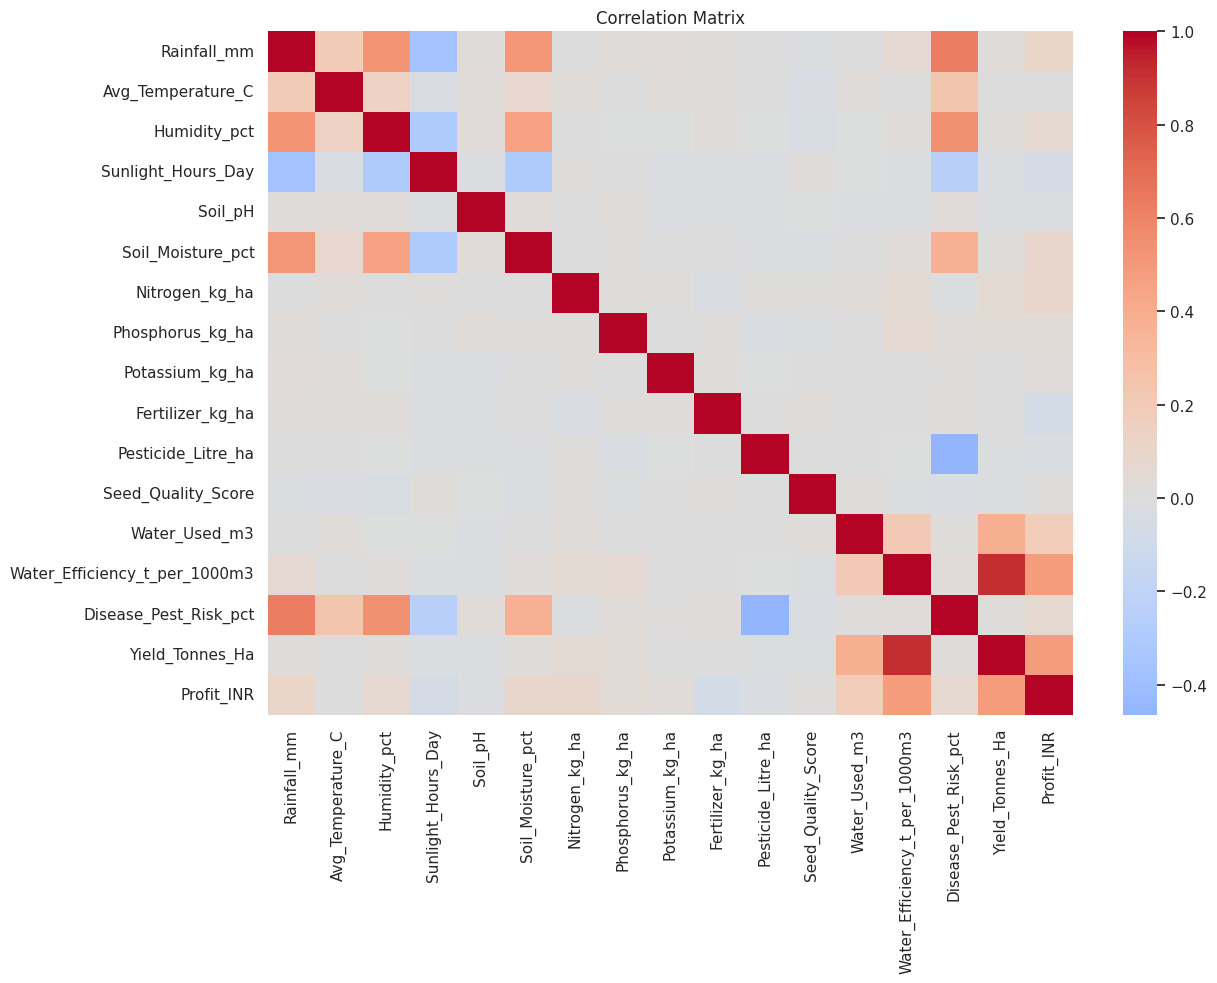

,Correlation_with_Yield
Yield_Tonnes_Ha,1.000
Water_Efficiency_t_per_1000m3,0.916
Profit_INR,0.489
Water_Used_m3,0.387
Nitrogen_kg_ha,0.054
Phosphorus_kg_ha,0.047
Rainfall_mm,0.027
Disease_Pest_Risk_pct,0.012
Humidity_pct,0.011
Soil_Moisture_pct,0.010


In [25]:
corr_cols = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct",
    "Yield_Tonnes_Ha",
    "Profit_INR"
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

yield_corr = corr_matrix["Yield_Tonnes_Ha"].sort_values(ascending=False)
display(yield_corr.to_frame("Correlation_with_Yield"))


## 22. Scatter Plots for Important Relationships

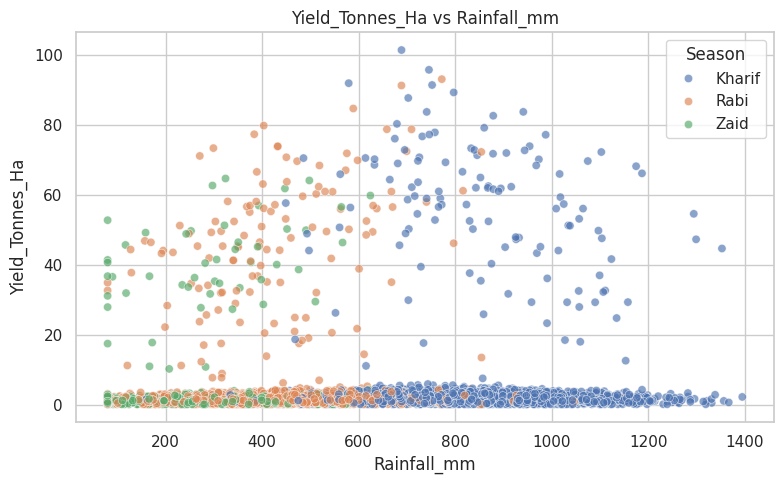

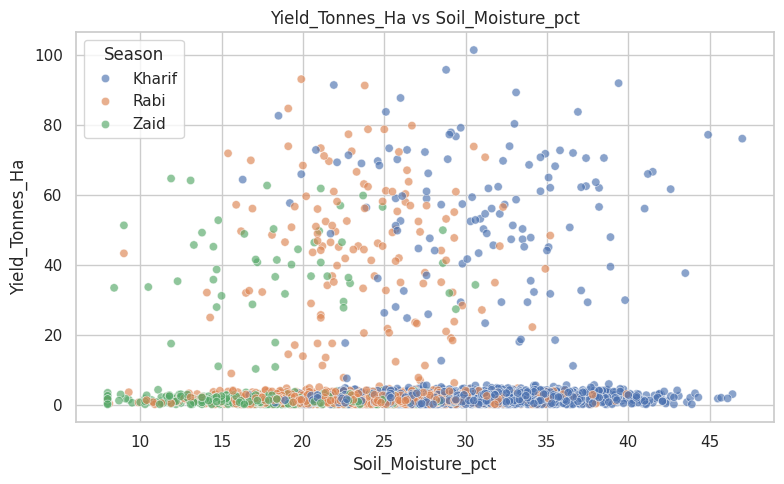

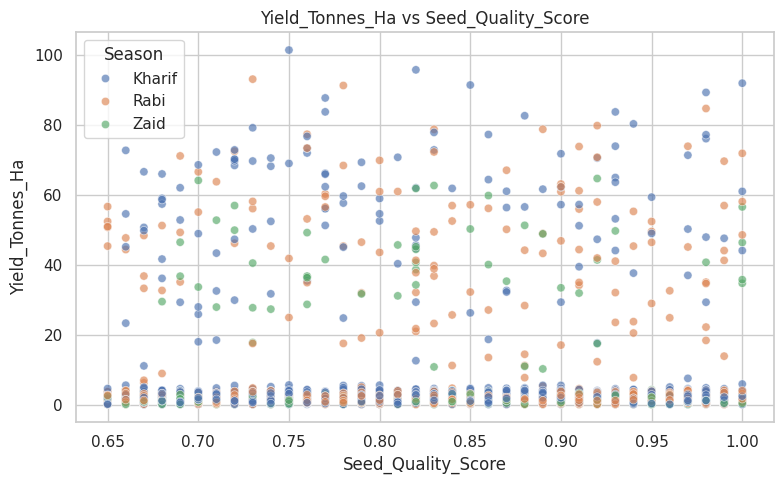

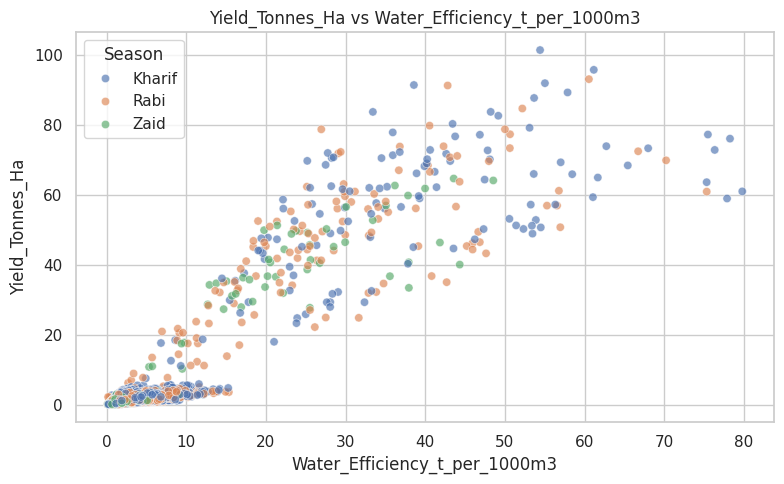

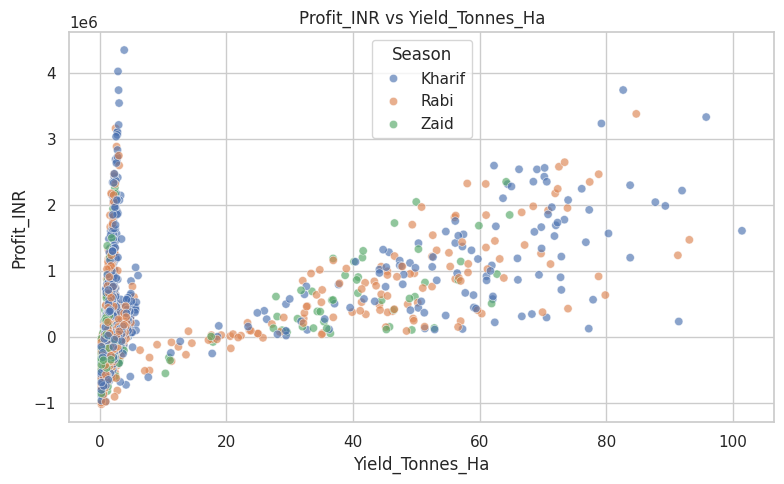

In [26]:
relationships = [
    ("Rainfall_mm", "Yield_Tonnes_Ha"),
    ("Soil_Moisture_pct", "Yield_Tonnes_Ha"),
    ("Seed_Quality_Score", "Yield_Tonnes_Ha"),
    ("Water_Efficiency_t_per_1000m3", "Yield_Tonnes_Ha"),
    ("Yield_Tonnes_Ha", "Profit_INR")
]

for x, y in relationships:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x=x, y=y, hue="Season", alpha=0.65)
    plt.title(f"{y} vs {x}")
    plt.tight_layout()
    plt.show()


## 23. Regional Analysis

,Farms,Avg_Yield,Avg_Profit,Avg_Water_Efficiency,Avg_Risk
State,,,,,
Punjab,484,6.121,"136,025.636",5.622,45.996
Karnataka,489,5.777,"119,422.335",5.562,46.055
Gujarat,488,5.752,"117,568.236",5.579,45.945
Telangana,516,5.049,"108,829.616",5.465,46.361
Maharashtra,512,5.017,"135,428.855",5.284,46.435
Madhya Pradesh,497,4.991,"86,840.757",5.267,47.081
Tamil Nadu,485,4.873,"117,744.748",5.305,46.284
Andhra Pradesh,529,4.629,"73,453.527",5.031,46.720


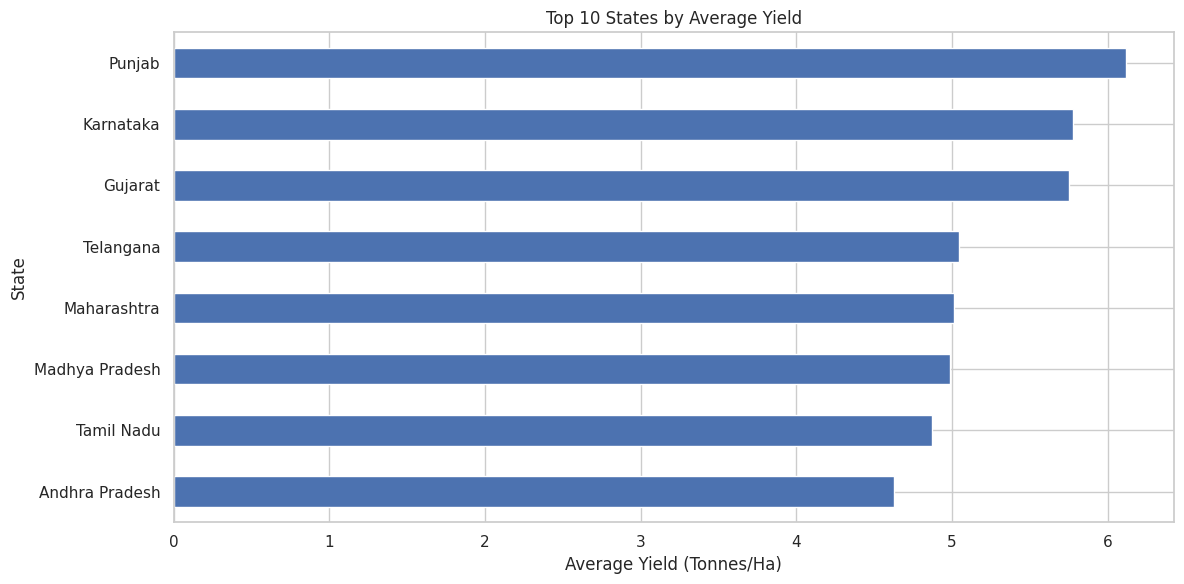

In [27]:
state_summary = df.groupby("State").agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Avg_Risk=("Disease_Pest_Risk_pct", "mean")
).sort_values("Avg_Yield", ascending=False).round(3)

display(state_summary)

plt.figure(figsize=(12, 6))
top_states = state_summary.head(10).sort_values("Avg_Yield")
top_states["Avg_Yield"].plot(kind="barh")
plt.title("Top 10 States by Average Yield")
plt.xlabel("Average Yield (Tonnes/Ha)")
plt.ylabel("State")
plt.tight_layout()
plt.show()


## 24. Crop-Level Consistency Across Seasons

In [28]:
crop_season_stats = df.groupby("Crop").agg(
    Mean_Yield=("Yield_Tonnes_Ha", "mean"),
    Yield_SD=("Yield_Tonnes_Ha", "std"),
    Mean_Profit=("Profit_INR", "mean"),
    Mean_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).sort_values("Mean_Yield", ascending=False).round(3)

display(crop_season_stats)

# Coefficient of variation for yield
crop_cv = (
    df.groupby("Crop")["Yield_Tonnes_Ha"]
      .agg(["mean", "std"])
      .assign(CV=lambda x: x["std"] / x["mean"])
      .sort_values("CV")
)

display(crop_cv.round(3))


,Mean_Yield,Yield_SD,Mean_Profit,Mean_Water_Efficiency
Crop,,,,
Sugarcane,46.929,21.019,"817,187.987",30.478
Maize,2.717,1.232,"-83,978.327",5.603
Rice,2.441,1.142,"-102,213.504",1.946
Wheat,2.110,0.914,"-123,398.337",4.628
Chilli,1.539,0.781,"750,878.342",2.948
Groundnut,1.318,0.604,"44,858.120",3.155
Cotton,1.226,0.523,"124,546.915",1.938
Pulses,0.918,0.423,"-4,238.052",2.897


,mean,std,CV
Crop,,,
Cotton,1.226,0.523,0.427
Wheat,2.110,0.914,0.433
Sugarcane,46.929,21.019,0.448
Maize,2.717,1.232,0.454
Groundnut,1.318,0.604,0.458
Pulses,0.918,0.423,0.461
Rice,2.441,1.142,0.468
Chilli,1.539,0.781,0.507


## 25. Statistical Test: Does Yield Differ by Season?

In [29]:
# One-way ANOVA
season_groups = [
    df.loc[df["Season"] == season, "Yield_Tonnes_Ha"]
    for season in df["Season"].dropna().unique()
]

anova_result = stats.f_oneway(*season_groups)

print("ANOVA F-statistic:", round(anova_result.statistic, 4))
print("ANOVA p-value:", anova_result.pvalue)

if anova_result.pvalue < 0.05:
    print("Conclusion: There is statistically significant evidence that mean yield differs across seasons (p < 0.05).")
else:
    print("Conclusion: The test does not provide sufficient evidence of a difference in mean yield across seasons (p >= 0.05).")


ANOVA F-statistic: 1.4579
ANOVA p-value: 0.2328474889882346
Conclusion: The test does not provide sufficient evidence of a difference in mean yield across seasons (p >= 0.05).


## 26. Non-Parametric Confirmation

In [30]:
# Kruskal-Wallis test is useful when distributions are not approximately normal.
kw_result = stats.kruskal(*season_groups)

print("Kruskal-Wallis statistic:", round(kw_result.statistic, 4))
print("Kruskal-Wallis p-value:", kw_result.pvalue)

if kw_result.pvalue < 0.05:
    print("Conclusion: Seasonal yield distributions differ significantly (p < 0.05).")
else:
    print("Conclusion: No statistically significant seasonal distribution difference was detected (p >= 0.05).")


Kruskal-Wallis statistic: 70.2646
Kruskal-Wallis p-value: 5.523734764890478e-16
Conclusion: Seasonal yield distributions differ significantly (p < 0.05).


## 27. Detecting Outliers in Yield

In [31]:
Q1 = df["Yield_Tonnes_Ha"].quantile(0.25)
Q3 = df["Yield_Tonnes_Ha"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["Yield_Tonnes_Ha"] < lower_bound) |
    (df["Yield_Tonnes_Ha"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of yield outliers:", len(outliers))

display(
    outliers[
        ["Farm_ID", "State", "District", "Crop", "Season", "Yield_Tonnes_Ha",
         "Production_Tonnes", "Profit_INR"]
    ].sort_values("Yield_Tonnes_Ha", ascending=False).head(20)
)


Q1: 1.05
Q3: 2.84
IQR: 1.7899999999999998
Lower bound: -1.6349999999999996
Upper bound: 5.5249999999999995
Number of yield outliers: 304


,Farm_ID,State,District,Crop,Season,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR
1715,SF11716,Gujarat,Indore,Sugarcane,Kharif,101.440,641.100,1608291
3423,SF13424,Andhra Pradesh,Indore,Sugarcane,Kharif,95.790,"1,424.400",3330582
3525,SF13526,Andhra Pradesh,Erode,Sugarcane,Rabi,93.130,648.180,1471529
1464,SF11465,Gujarat,Nashik,Sugarcane,Kharif,91.980,703.650,2216708
3523,SF13524,Karnataka,Nashik,Sugarcane,Kharif,91.460,75.000,234320
2782,SF12783,Gujarat,Nalgonda,Sugarcane,Rabi,91.320,522.350,1236801
644,SF10645,Andhra Pradesh,Ludhiana,Sugarcane,Kharif,89.340,668.260,1984818
2847,SF12848,Telangana,Warangal,Sugarcane,Kharif,87.760,672.240,2041678
357,SF10358,Punjab,Warangal,Sugarcane,Rabi,84.750,"1,249.210",3378879
1178,SF11179,Karnataka,Nalgonda,Sugarcane,Kharif,83.790,534.580,1200815


## 28. Highest- and Lowest-Performing Season-Crop Groups

In [32]:
group_performance = df.groupby(["Season", "Crop"]).agg(
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Avg_Risk=("Disease_Pest_Risk_pct", "mean"),
    Farms=("Farm_ID", "count")
).sort_values("Avg_Yield", ascending=False).round(3)

print("Top 10 Season-Crop groups by average yield:")
display(group_performance.head(10))

print("Bottom 10 Season-Crop groups by average yield:")
display(group_performance.tail(10))


Top 10 Season-Crop groups by average yield:


Avg_Yield    Avg_Profit  Avg_Water_Efficiency  Avg_Risk  \
Season Crop                                                                 
Kharif Sugarcane     53.459 1,000,790.808                36.004    54.016   
Rabi   Sugarcane     43.964   731,612.860                27.925    39.846   
Zaid   Sugarcane     38.424   583,635.804                23.391    38.355   
Kharif Maize          2.966   -39,332.671                 6.055    54.818   
       Rice           2.709   -64,903.404                 2.169    54.255   
Rabi   Maize          2.617   -89,133.403                 5.458    39.415   
       Rice           2.335   -98,427.869                 1.844    40.787   
Zaid   Maize          2.297  -194,049.167                 4.746    36.682   
Kharif Wheat          2.256  -105,871.870                 4.758    55.581   
Rabi   Wheat          2.060  -119,954.565                 4.687    41.455   

                  Farms  
Season Crop              
Kharif Sugarcane    125  
Rabi   Sugarcane    129  
Zaid   Sugarcane     51  
Kharif Maize        234  
       Rice         314  
Rabi   Maize        233  
       Rice         274  
Zaid   Maize         84  
Kharif Wheat        292  
Rabi   Wheat        237

Bottom 10 Season-Crop groups by average yield:


Avg_Yield   Avg_Profit  Avg_Water_Efficiency  Avg_Risk  \
Season Crop                                                                
Rabi   Chilli         1.463  638,572.497                 2.886    40.589   
Kharif Cotton         1.373  216,999.549                 2.131    54.242   
Rabi   Groundnut      1.223   10,416.542                 2.897    39.763   
       Cotton         1.193  107,343.587                 1.938    41.540   
Zaid   Chilli         1.179  448,659.094                 2.204    40.503   
       Groundnut      1.038  -68,872.500                 2.465    39.128   
Kharif Pulses         1.036   43,338.896                 3.352    54.960   
Zaid   Cotton         0.952  -53,925.337                 1.489    36.342   
Rabi   Pulses         0.872  -14,309.136                 2.699    40.078   
Zaid   Pulses         0.652 -139,227.806                 1.950    38.966   

                  Farms  
Season Crop              
Rabi   Chilli       163  
Kharif Cotton       215  
Rabi   Groundnut    177  
       Cotton       201  
Zaid   Chilli        64  
       Groundnut     54  
Kharif Pulses       221  
Zaid   Cotton        92  
Rabi   Pulses       213  
Zaid   Pulses        62

## 29. Overall Ranking of Seasons

,Yield,Profit,Water_Efficiency,Risk,Yield_norm,Profit_norm,Water_Efficiency_norm,Risk_norm,Overall_Score
Season,,,,,,,,,
Kharif,5.631,"178,914.648",5.892,54.468,1.000,1.000,1.000,0.000,0.900
Rabi,5.095,"87,689.470",5.186,40.482,0.461,0.552,0.523,0.861,0.545
Zaid,4.637,"-24,804.825",4.413,38.217,0.000,0.000,0.000,1.000,0.100


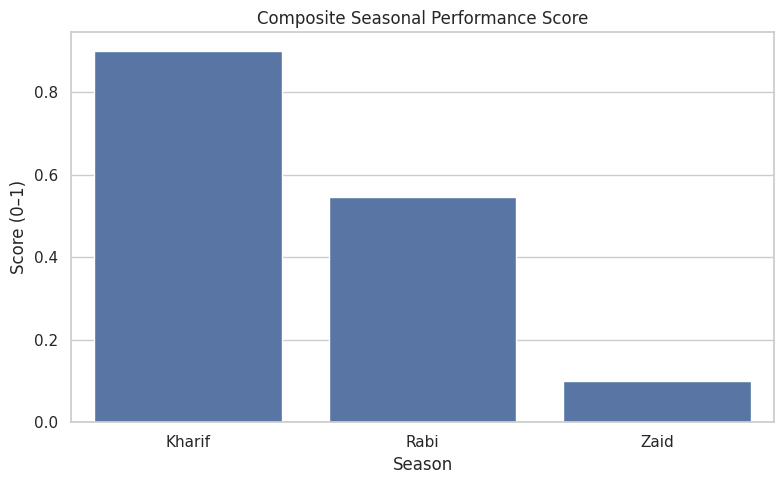

In [33]:
season_score = df.groupby("Season").agg(
    Yield=("Yield_Tonnes_Ha", "mean"),
    Profit=("Profit_INR", "mean"),
    Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Risk=("Disease_Pest_Risk_pct", "mean")
)

# Normalize positive indicators and inverse-normalize risk.
for col in ["Yield", "Profit", "Water_Efficiency"]:
    min_v, max_v = season_score[col].min(), season_score[col].max()
    season_score[col + "_norm"] = (season_score[col] - min_v) / (max_v - min_v) if max_v != min_v else 0.5

min_v, max_v = season_score["Risk"].min(), season_score["Risk"].max()
season_score["Risk_norm"] = (
    (max_v - season_score["Risk"]) / (max_v - min_v)
    if max_v != min_v else 0.5
)

season_score["Overall_Score"] = (
    0.35 * season_score["Yield_norm"] +
    0.35 * season_score["Profit_norm"] +
    0.20 * season_score["Water_Efficiency_norm"] +
    0.10 * season_score["Risk_norm"]
)

season_score = season_score.sort_values("Overall_Score", ascending=False)
display(season_score.round(3))

plt.figure(figsize=(8, 5))
sns.barplot(
    x=season_score.index,
    y=season_score["Overall_Score"].values,
    errorbar=None
)
plt.title("Composite Seasonal Performance Score")
plt.xlabel("Season")
plt.ylabel("Score (0–1)")
plt.tight_layout()
plt.show()


## 30. Key Findings — Generate Evidence Automatically

In [34]:
best_yield_season = season_yield["mean"].idxmax()
best_yield_value = season_yield.loc[best_yield_season, "mean"]

best_profit_season = economic_summary["Profit_INR"].idxmax()
best_profit_value = economic_summary.loc[best_profit_season, "Profit_INR"]

best_water_season = water_summary["Avg_Water_Efficiency"].idxmax()
best_water_value = water_summary.loc[best_water_season, "Avg_Water_Efficiency"]

highest_risk_season = risk_summary["mean"].idxmax()
highest_risk_value = risk_summary.loc[highest_risk_season, "mean"]

best_group = group_performance.index[0]
best_group_yield = group_performance.iloc[0]["Avg_Yield"]

print(f"1. Highest average seasonal yield: {best_yield_season} ({best_yield_value:.3f} Tonnes/Ha).")
print(f"2. Highest average seasonal profit: {best_profit_season} (INR {best_profit_value:,.2f}).")
print(f"3. Highest average water efficiency: {best_water_season} ({best_water_value:.3f} tonnes/1000 m³).")
print(f"4. Highest average disease/pest risk: {highest_risk_season} ({highest_risk_value:.2f}%).")
print(f"5. Best Season-Crop group by average yield: {best_group[0]} + {best_group[1]} ({best_group_yield:.3f} Tonnes/Ha).")

print("\nStatistical evidence:")
print(f"ANOVA p-value = {anova_result.pvalue:.6g}")
print(f"Kruskal-Wallis p-value = {kw_result.pvalue:.6g}")


1. Highest average seasonal yield: Kharif (5.631 Tonnes/Ha).
2. Highest average seasonal profit: Kharif (INR 178,914.65).
3. Highest average water efficiency: Kharif (5.892 tonnes/1000 m³).
4. Highest average disease/pest risk: Kharif (54.47%).
5. Best Season-Crop group by average yield: Kharif + Sugarcane (53.459 Tonnes/Ha).

Statistical evidence:
ANOVA p-value = 0.232847
Kruskal-Wallis p-value = 5.52373e-16


## 31. Conclusions

Based on the analysis, the final conclusions should focus on:

- **Seasonal variation:** compare average and median yield, production, profit, water efficiency, and risk across Kharif, Rabi, and Zaid.
- **Crop suitability:** identify crops whose yield remains strong in particular seasons.
- **Environmental influence:** compare rainfall, soil moisture, temperature, humidity, sunlight, and soil pH with yield.
- **Resource management:** examine fertilizer, nutrients, irrigation, pesticide, and water use.
- **Economic performance:** a high yield does not automatically mean high profit; cost and market price must also be considered.
- **Water sustainability:** seasons/crops with higher water efficiency can be prioritized where water availability is limited.
- **Risk management:** higher disease/pest risk should be considered while planning crop and season combinations.
- **Regional planning:** state-level differences show that seasonal planning should also account for geographical conditions.

### Important interpretation note
Correlation does **not** prove causation. A strong relationship between two variables means they move together in this dataset, but it does not prove that one variable directly causes the other.


## 32. Recommendations

1. Select crops according to their observed seasonal yield and profitability.
2. Prefer water-efficient crop-season combinations in water-constrained areas.
3. Use environmental indicators such as rainfall and soil moisture for irrigation planning.
4. Monitor disease/pest risk before and during high-risk seasons.
5. Avoid judging agricultural success from yield alone; consider profit, cost, market price, and resource efficiency.
6. Investigate high-performing outliers to understand whether specific farming practices can be replicated.
7. Use state-level analysis for region-specific agricultural planning.
8. For future work, apply predictive models such as Random Forest, XGBoost, or regression to predict yield/profit.


## 33. Final Project Summary

This project transformed raw agricultural records into interpretable evidence using:

- Data cleaning and missing-value treatment
- Descriptive statistics
- Seasonal and crop comparisons
- Environmental analysis
- Resource-use analysis
- Economic analysis
- Water-efficiency analysis
- Correlation analysis
- Regional analysis
- Outlier detection
- ANOVA and Kruskal-Wallis statistical tests
- Data visualization
- Evidence-based conclusions and recommendations

**Project outcome:** The analysis provides a structured way to understand how season, crop, environment, resources, risk, and economics interact in agricultural performance.
